# Week 9: Gradient Boosting

Project Background and Context
Project Overview

This project investigates the factors associated with high motor vehicle fatality rates across counties in the United States. The objective is to determine whether county-level demographic, transportation, and Federal Emergency Management Agency (FEMA) National Risk Index variables can be used to classify counties as having either High Fatality or Not High Fatality crash rates.

Data Sources

The dataset was created by combining multiple publicly available sources:

Fatality Analysis Reporting System (FARS) accident records from the National Highway Traffic Safety Administration (NHTSA)
FEMA National Risk Index county-level resilience and risk measures
U.S. Census Bureau county population estimates

These sources were merged using county level geographic identifiers to produce one observation per county.

Target Variable

The response variable is a binary classification indicating whether a county belongs to the High Fatality group.

0 = Not High Fatality
1 = High Fatality

The classes are moderately imbalanced, with approximately 75% of counties classified as Not High Fatality and 25% classified as High Fatality. Because correctly identifying the minority High Fatality class is important, model performance is evaluated primarily using F1 score, recall, and ROC-AUC rather than overall accuracy alone.

Predictor Variables

The models use seven county-level predictor variables:

PERSONS – number of persons involved per fatal crash
VE_TOTAL – number of vehicles involved per fatal crash
PEDS – pedestrian involvement in fatal crashes
poverty_rate – County poverty rate from Census data
RISK_SCORE – FEMA National Risk Index overall county risk score
SOVI_SCORE – FEMA National Risk Index Social Vulnerability score
RESL_SCORE – FEMA National Risk Index Community Resilience score

Previous analyses performed during earlier weeks consistently found that RESL_SCORE and RISK_SCORE are the strongest predictors of county fatality classification.

Prior weeks evaluated several supervised learning algorithms, including:

Linear and Polynomial Regression
Logistic Regression
Support Vector Machines
Decision Trees
Random Forests
K-Nearest Neighbors

Among these models, Random Forests and tuned Logistic Regression have generally produced the strongest predictive performance. This week's notebook extends the comparison by evaluating Gradient Boosting, including experiments involving learning rate, number of boosting estimators, weak-learner depth, regularization, and hyperparameter tuning.

Purpose of This Notebook

The objective of this notebook is to look at how Gradient Boosting performs on the county fatality classification problem and to compare its performance with previous models.

In [ ]:
# ============================================================
# Week 9 evaluation helper
# ============================================================

def gradient_boost_cv_f1(model, X, y, cv):
    """
    Calculate cross-validation F1 using balanced sample weights
    separately within each training fold.
    """

    fold_scores = []

    for train_index, validation_index in cv.split(X, y):

        X_fold_train = X.iloc[train_index]
        X_fold_validation = X.iloc[validation_index]

        y_fold_train = y.iloc[train_index]
        y_fold_validation = y.iloc[validation_index]

        fold_weights = compute_sample_weight(
            class_weight='balanced',
            y=y_fold_train)

        model_clone = clone(model)

        model_clone.fit(
            X_fold_train,
            y_fold_train,
            sample_weight=fold_weights)

        validation_predictions = model_clone.predict(
            X_fold_validation)

        fold_scores.append(
            f1_score(
                y_fold_validation,
                validation_predictions,
                zero_division=0
            ))

    return np.array(fold_scores)


def evaluate_gradient_boost_model(
    model_name,
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    notes=''):
    """
    Fit and evaluate one Gradient Boosting classifier.
    """

    sample_weights = compute_sample_weight(
        class_weight='balanced',
        y=y_train)

    model.fit(
        X_train,
        y_train,
        sample_weight=sample_weights)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    cv_scores = gradient_boost_cv_f1(
        model,
        X_train,
        y_train,
        CV_GB)

    row = {
        'model': model_name,

        'train_accuracy': accuracy_score(
            y_train,
            y_train_pred
        ),
        'test_accuracy': accuracy_score(
            y_test,
            y_test_pred
        ),

        'train_precision': precision_score(
            y_train,
            y_train_pred,
            zero_division=0
        ),
        'test_precision': precision_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        'train_recall': recall_score(
            y_train,
            y_train_pred,
            zero_division=0
        ),
        'test_recall': recall_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        'train_f1': f1_score(
            y_train,
            y_train_pred,
            zero_division=0
        ),
        'test_f1': f1_score(
            y_test,
            y_test_pred,
            zero_division=0
        ),

        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),

        'test_roc_auc': roc_auc_score(
            y_test,
            y_test_prob
        ),'notes': notes}

    week9_results.append(row)
    classification_results.append(row)

    return row, y_test_pred, y_test_prob

In [208]:
# ============================================================
# 1. Baseline Gradient Boosting
# ============================================================
from sklearn.base import clone

baseline_gradient_boost = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=RANDOM_STATE)

baseline_gb_row, baseline_gb_pred, baseline_gb_prob = (
    evaluate_gradient_boost_model(
        model_name='Gradient Boosting Baseline',
        model=baseline_gradient_boost,
        X_train=X_train_cls,
        X_test=X_test_cls,
        y_train=y_train_cls,
        y_test=y_test_cls,
        notes=(
            'Baseline Gradient Boosting with 100 estimators, '
            'learning rate 0.1, and maximum tree depth 3.')))

baseline_gb_row

{'model': 'Gradient Boosting Baseline',
 'train_accuracy': 0.7972370766488414,
 'test_accuracy': 0.7611408199643493,
 'train_precision': 0.560315670800451,
 'test_precision': 0.5142857142857142,
 'train_recall': 0.8843416370106761,
 'test_recall': 0.7714285714285715,
 'train_f1': 0.6859903381642513,
 'test_f1': 0.6171428571428571,
 'cv_f1_mean': np.float64(0.5666768225501899),
 'cv_f1_std': np.float64(0.02634009560334845),
 'test_roc_auc': 0.8359942314217848,
 'notes': 'Baseline Gradient Boosting with 100 estimators, learning rate 0.1, and maximum tree depth 3.'}

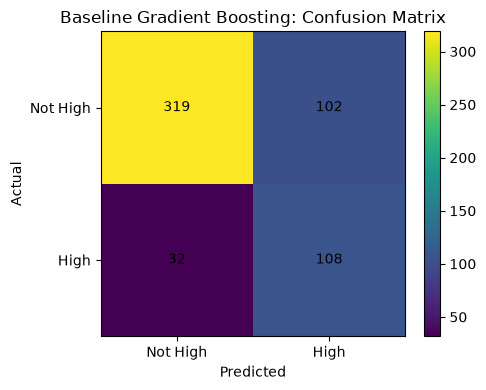

              precision    recall  f1-score   support

    Not High       0.91      0.76      0.83       421
        High       0.51      0.77      0.62       140

    accuracy                           0.76       561
   macro avg       0.71      0.76      0.72       561
weighted avg       0.81      0.76      0.77       561



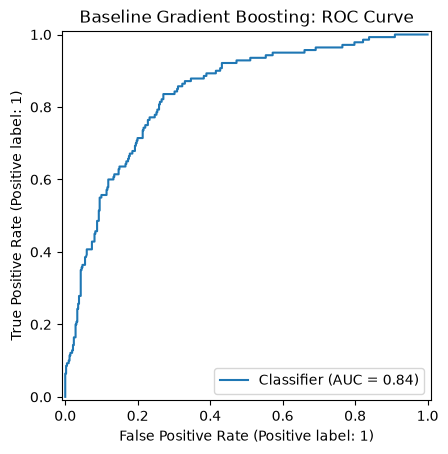

In [209]:
# ============================================================
# Baseline Gradient Boosting results
# ============================================================

plot_confusion_matrix(
    y_test_cls,
    baseline_gb_pred,
    'Baseline Gradient Boosting: Confusion Matrix')

print(
    classification_report(
        y_test_cls,
        baseline_gb_pred,
        target_names=['Not High', 'High']
    ))

RocCurveDisplay.from_predictions(
    y_test_cls,
    baseline_gb_prob)

plt.title('Baseline Gradient Boosting: ROC Curve')
plt.show()

In [211]:
# ============================================================
# 2. Learning-rate comparison
# ============================================================

learning_rates = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.50,
    1.00]

learning_rate_rows = []

for learning_rate in learning_rates:

    candidate_model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=learning_rate,
        max_depth=2,
        random_state=RANDOM_STATE)

    cv_scores = gradient_boost_cv_f1(
        candidate_model,
        X_train_cls,
        y_train_cls,
        CV_GB)

    learning_rate_rows.append({
        'learning_rate': learning_rate,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()})

learning_rate_results = pd.DataFrame(
    learning_rate_rows)

display(learning_rate_results)

,learning_rate,cv_f1_mean,cv_f1_std
0,0.01,0.524732,0.021173
1,0.05,0.555089,0.029137
2,0.10,0.564581,0.029155
3,0.20,0.568680,0.022421
4,0.50,0.526542,0.029382
5,1.00,0.489239,0.021130


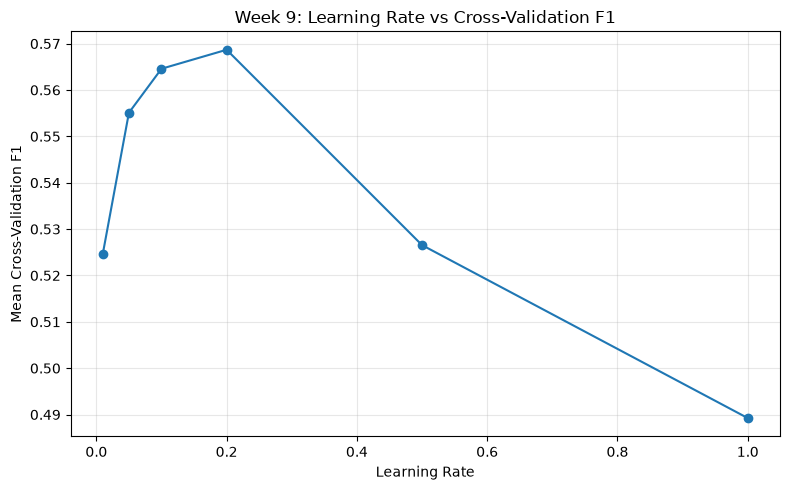

In [212]:
plt.figure(figsize=(8, 5))

plt.plot(
    learning_rate_results['learning_rate'],
    learning_rate_results['cv_f1_mean'],
    marker='o')

plt.xlabel('Learning Rate')
plt.ylabel('Mean Cross-Validation F1')
plt.title('Week 9: Learning Rate vs Cross-Validation F1')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [213]:
# ============================================================
# 3. Number of estimators comparison
# ============================================================

estimator_values = [
    10,
    25,
    50,
    100,
    200,
    300,
    500]

estimator_rows = []

for number_of_estimators in estimator_values:

    candidate_model = GradientBoostingClassifier(
        n_estimators=number_of_estimators,
        learning_rate=0.1,
        max_depth=2,
        random_state=RANDOM_STATE)

    cv_scores = gradient_boost_cv_f1(
        candidate_model,
        X_train_cls,
        y_train_cls,
        CV_GB)

    estimator_rows.append({
        'n_estimators': number_of_estimators,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()})

estimator_results = pd.DataFrame(
    estimator_rows)

display(estimator_results)

,n_estimators,cv_f1_mean,cv_f1_std
0,10,0.523235,0.021771
1,25,0.553090,0.018104
2,50,0.555990,0.028338
3,100,0.564581,0.029155
4,200,0.556823,0.029286
5,300,0.548963,0.024290
6,500,0.533704,0.032597


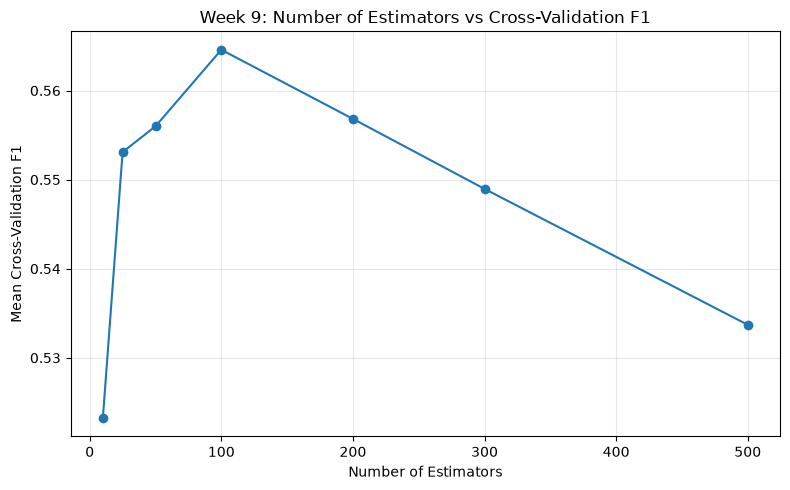

In [214]:
plt.figure(figsize=(8, 5))

plt.plot(
    estimator_results['n_estimators'],
    estimator_results['cv_f1_mean'],
    marker='o')

plt.xlabel('Number of Estimators')
plt.ylabel('Mean Cross-Validation F1')
plt.title(
    'Week 9: Number of Estimators vs Cross-Validation F1')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [215]:
# ============================================================
# 4. Weak-learner tree-depth comparison
# ============================================================

depth_values = [
    1,
    2,
    3,
    4,
    5]

depth_rows = []

for depth in depth_values:

    candidate_model = GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=depth,
        random_state=RANDOM_STATE)

    cv_scores = gradient_boost_cv_f1(
        candidate_model,
        X_train_cls,
        y_train_cls,
        CV_GB)

    depth_rows.append({
        'max_depth': depth,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std()})

depth_results = pd.DataFrame(
    depth_rows)

display(depth_results)

,max_depth,cv_f1_mean,cv_f1_std
0,1,0.556514,0.038910
1,2,0.564581,0.029155
2,3,0.566677,0.026340
3,4,0.571802,0.028781
4,5,0.560318,0.033182


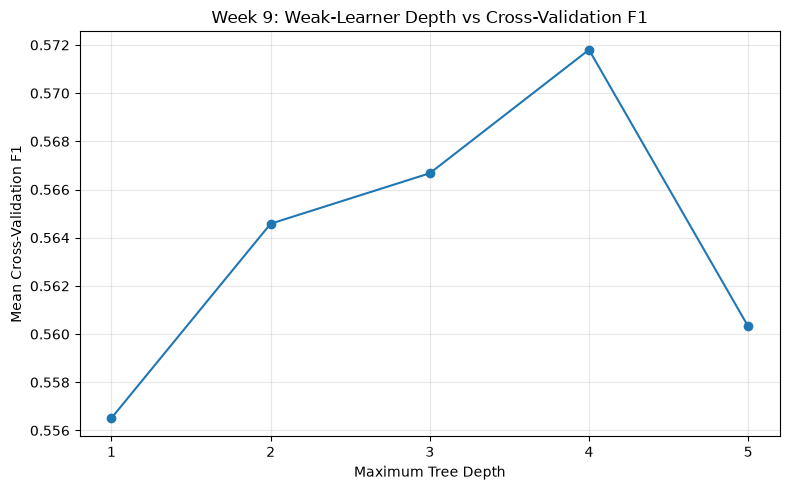

In [216]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results['max_depth'],
    depth_results['cv_f1_mean'],
    marker='o')

plt.xlabel('Maximum Tree Depth')
plt.ylabel('Mean Cross-Validation F1')
plt.title(
    'Week 9: Weak-Learner Depth vs Cross-Validation F1')
plt.xticks(depth_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [217]:
# ============================================================
# 5. Gradient Boosting regularization
# ============================================================

subsample_values = [
    0.5,
    0.7,
    0.9,
    1.0]

leaf_values = [
    1,
    5,
    10,
    20,
    40]

regularization_rows = []

for subsample_value in subsample_values:

    for leaf_value in leaf_values:

        candidate_model = GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=2,
            subsample=subsample_value,
            min_samples_leaf=leaf_value,
            random_state=RANDOM_STATE)

        cv_scores = gradient_boost_cv_f1(
            candidate_model,
            X_train_cls,
            y_train_cls,
            CV_GB        )

        regularization_rows.append({
            'subsample': subsample_value,
            'min_samples_leaf': leaf_value,
            'cv_f1_mean': cv_scores.mean(),
            'cv_f1_std': cv_scores.std()        })

regularization_results = pd.DataFrame(
    regularization_rows)

display(
    regularization_results
    .sort_values(
        'cv_f1_mean',
        ascending=False
    )
    .head(10))

,subsample,min_samples_leaf,cv_f1_mean,cv_f1_std
0,0.5,1,0.576083,0.035001
4,0.5,40,0.573696,0.032734
6,0.7,5,0.570926,0.029308
1,0.5,5,0.570500,0.033453
7,0.7,10,0.569367,0.026489
11,0.9,5,0.568465,0.032266
14,0.9,40,0.568464,0.025986
3,0.5,20,0.568024,0.037147
8,0.7,20,0.567471,0.028503
5,0.7,1,0.565745,0.029456


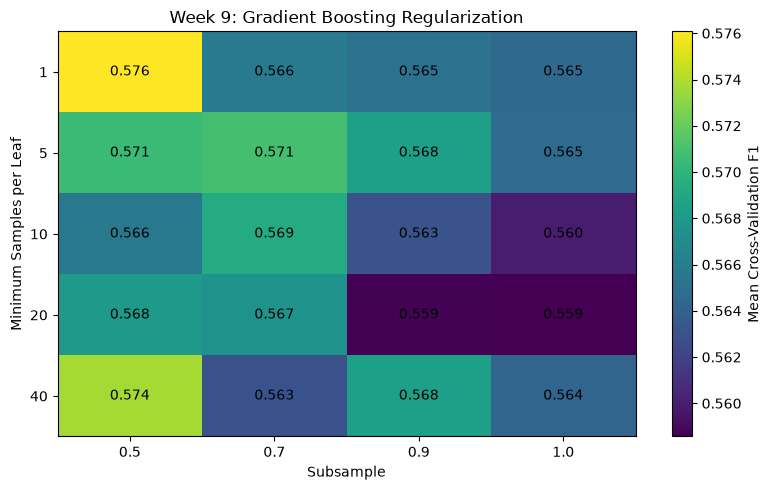

In [218]:
regularization_pivot = regularization_results.pivot(
    index='min_samples_leaf',
    columns='subsample',
    values='cv_f1_mean')

plt.figure(figsize=(8, 5))

plt.imshow(
    regularization_pivot,
    aspect='auto')

plt.colorbar(label='Mean Cross-Validation F1')

plt.xticks(
    range(len(regularization_pivot.columns)),
    regularization_pivot.columns)

plt.yticks(
    range(len(regularization_pivot.index)),
    regularization_pivot.index)

plt.xlabel('Subsample')
plt.ylabel('Minimum Samples per Leaf')
plt.title('Week 9: Gradient Boosting Regularization')

for row_index in range(
    regularization_pivot.shape[0]):
    for column_index in range(
        regularization_pivot.shape[1]
    ):
        plt.text(
            column_index,
            row_index,
            f'{regularization_pivot.iloc[row_index, column_index]:.3f}',
            ha='center',
            va='center'        )

plt.tight_layout()
plt.show()

In [228]:
# ============================================================
# 6. Tune the complete Gradient Boosting model
# ============================================================

def unweighted_f1_scorer(
    estimator,
    X_validation,
    y_validation):
    validation_pred = estimator.predict(X_validation)

    return f1_score(
        y_validation,
        validation_pred,
        zero_division=0    )


gradient_boost_grid_model = GradientBoostingClassifier(
    random_state=RANDOM_STATE)

gradient_boost_grid = {
    'learning_rate': [
        0.05,
        0.10
    ],
    'n_estimators': [
        100,
        200
    ],
    'max_depth': [
        1,
        2,
        3
    ],
    'subsample': [
        0.7,
        1.0
    ],
    'min_samples_leaf': [
        10,
        25]}

gradient_boost_search = GridSearchCV(
    estimator=gradient_boost_grid_model,
    param_grid=gradient_boost_grid,
    cv=CV_GB,
    scoring=unweighted_f1_scorer,
    n_jobs=-1,
    return_train_score=True,
    verbose=1)

gradient_boost_search.fit(
    X_train_cls,
    y_train_cls,
    sample_weight=train_sample_weights)

print('Best Gradient Boosting parameters:')
print(gradient_boost_search.best_params_)

print(
    '\nBest Gradient Boosting CV F1:',
    gradient_boost_search.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/model_selection/_search.py:921: UserWarning: The scoring <function unweighted_f1_scorer at 0x70696478c0e0> does not support sample_weight, which may lead to statistically incorrect results when fitting GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=GradientBoostingClassifier(random_state=42), n_jobs=-1,
             param_grid={'learning_rate': [0.05, 0.1], 'max_depth': [1, 2, 3],
                         'min_samples_leaf': [10, 25],
                         'n_estimators': [100, 200], 'subsample': [0.7, 1.0]},
             return_train_score=True,
             scoring=<function unweighted_f1_scorer at 0x70696478c0e0>,
             verbose=1) with sample_weight. 
  warnings.warn(


Best Gradient Boosting parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 25, 'n_estimators': 100, 'subsample': 0.7}

Best Gradient Boosting CV F1: 0.5741426155969904


In [229]:
best_gb_params = (
    gradient_boost_search.best_params_)

tuned_gb_row, tuned_gb_pred, tuned_gb_prob = (
    evaluate_gradient_boost_model(
        model_name='Gradient Boosting Tuned',
        model=gradient_boost_search.best_estimator_,
        X_train=X_train_cls,
        X_test=X_test_cls,
        y_train=y_train_cls,
        y_test=y_test_cls,
        notes=(
            'Tuned Gradient Boosting. '
            f'Best parameters = {best_gb_params}.')))

tuned_gb_row

{'model': 'Gradient Boosting Tuned',
 'train_accuracy': 0.750445632798574,
 'test_accuracy': 0.7557932263814616,
 'train_precision': 0.5010615711252654,
 'test_precision': 0.5067264573991032,
 'train_recall': 0.8398576512455516,
 'test_recall': 0.8071428571428572,
 'train_f1': 0.6276595744680851,
 'test_f1': 0.6225895316804407,
 'cv_f1_mean': np.float64(0.5726631975116632),
 'cv_f1_std': np.float64(0.02305861239744263),
 'test_roc_auc': 0.8390566677977604,
 'notes': "Tuned Gradient Boosting. Best parameters = {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 25, 'n_estimators': 100, 'subsample': 0.7}."}

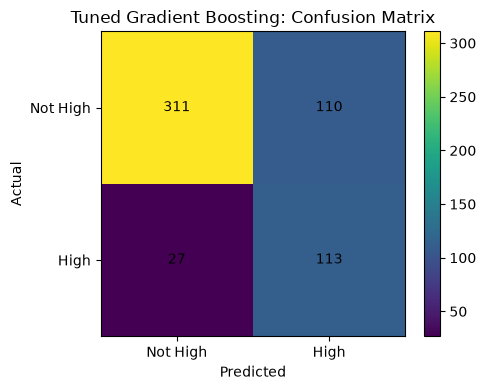

              precision    recall  f1-score   support

    Not High       0.92      0.74      0.82       421
        High       0.51      0.81      0.62       140

    accuracy                           0.76       561
   macro avg       0.71      0.77      0.72       561
weighted avg       0.82      0.76      0.77       561



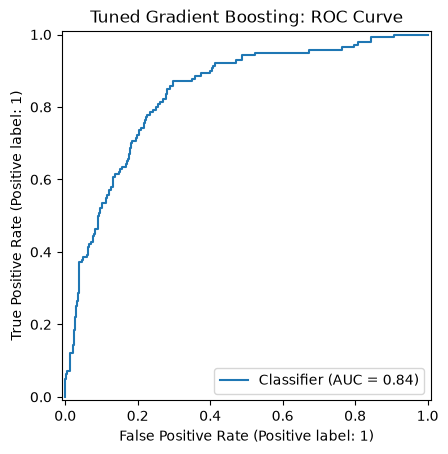

In [230]:
plot_confusion_matrix(
    y_test_cls,
    tuned_gb_pred,
    'Tuned Gradient Boosting: Confusion Matrix')

print(
    classification_report(
        y_test_cls,
        tuned_gb_pred,
        target_names=['Not High', 'High']
    ))

RocCurveDisplay.from_predictions(
    y_test_cls,
    tuned_gb_prob)

plt.title('Tuned Gradient Boosting: ROC Curve')
plt.show()

,feature,importance
6,RESL_SCORE,0.418291
4,RISK_SCORE,0.251093
3,poverty_rate,0.079340
0,PERSONS,0.079171
2,PEDS,0.067366
5,SOVI_SCORE,0.063335
1,VE_TOTAL,0.041404


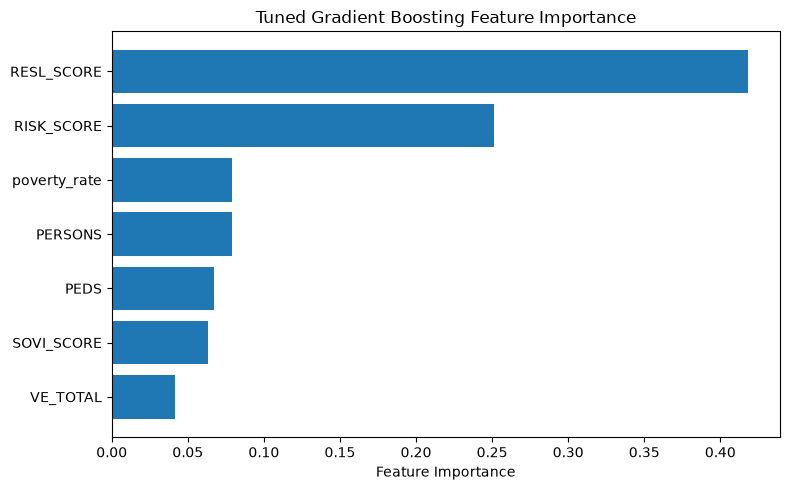

In [231]:
# ============================================================
# 7. Feature importance
# ============================================================

tuned_gradient_boost = (
    gradient_boost_search.best_estimator_)

gradient_boost_importance_df = pd.DataFrame({
    'feature': X_train_cls.columns,
    'importance': tuned_gradient_boost.feature_importances_
}).sort_values(
    'importance',
    ascending=False)

display(gradient_boost_importance_df)

plt.figure(figsize=(8, 5))

plt.barh(
    gradient_boost_importance_df['feature'][::-1],
    gradient_boost_importance_df['importance'][::-1])

plt.xlabel('Feature Importance')
plt.title('Tuned Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

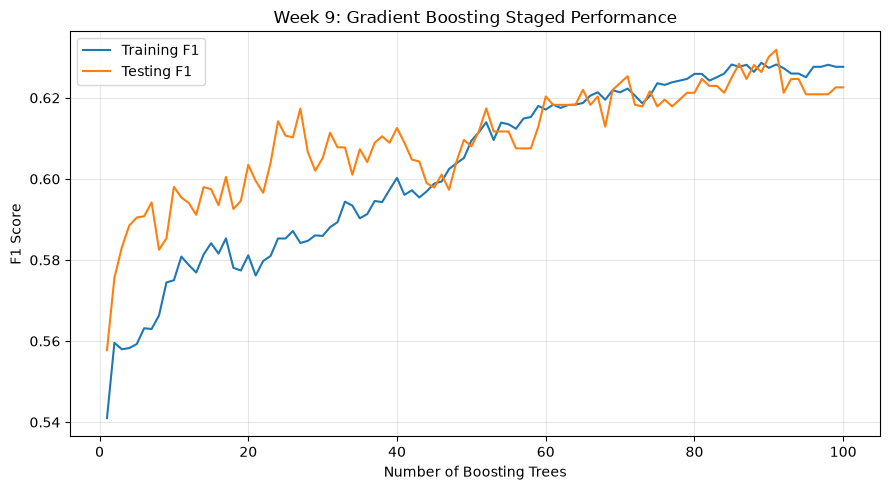

In [232]:
# ============================================================
# 8. Staged improvement
# ==========================================================

train_stage_f1 = []
test_stage_f1 = []

for train_stage_pred, test_stage_pred in zip(
    tuned_gradient_boost.staged_predict(X_train_cls),
    tuned_gradient_boost.staged_predict(X_test_cls)):

    train_stage_f1.append(
        f1_score(
            y_train_cls,
            train_stage_pred,
            zero_division=0))

    test_stage_f1.append(
        f1_score(
            y_test_cls,
            test_stage_pred,
            zero_division=0))

stage_numbers = range(
    1,
    len(train_stage_f1) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    stage_numbers,
    train_stage_f1,
    label='Training F1')

plt.plot(
    stage_numbers,
    test_stage_f1,
    label='Testing F1')

plt.xlabel('Number of Boosting Trees')
plt.ylabel('F1 Score')
plt.title('Week 9: Gradient Boosting Staged Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [233]:
# ============================================================
# 9. Week 9 comparison
# ============================================================

week9_results_df = (
    pd.DataFrame(week9_results)
    .drop_duplicates(
        subset='model',
        keep='last').sort_values(
        'test_f1',
        ascending=False).reset_index(drop=True))

display(week9_results_df)

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,cv_f1_mean,cv_f1_std,test_roc_auc,notes
0,Gradient Boosting Tuned,0.750446,0.755793,0.501062,0.506726,0.839858,0.807143,0.62766,0.622590,0.572663,0.023059,0.839057,Tuned Gradient Boosting. Best parameters = {'l...
1,Gradient Boosting Baseline,0.797237,0.761141,0.560316,0.514286,0.884342,0.771429,0.68599,0.617143,0.566677,0.026340,0.835994,Baseline Gradient Boosting with 100 estimators...


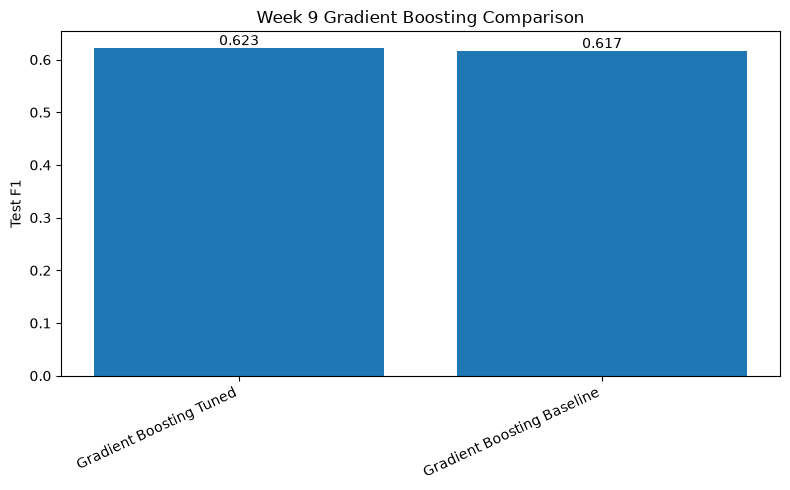

In [234]:
plt.figure(figsize=(8, 5))

plt.bar(
    week9_results_df['model'],
    week9_results_df['test_f1'])

plt.ylabel('Test F1')
plt.title('Week 9 Gradient Boosting Comparison')
plt.xticks(rotation=25, ha='right')

for index, value in enumerate(
    week9_results_df['test_f1']):
    plt.text(
        index,
        value + 0.005,
        f'{value:.3f}',
        ha='center')

plt.tight_layout()
plt.show()

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,cv_f1_mean,cv_f1_std,test_roc_auc,notes
0,Random Forest,0.999109,0.802139,0.996454,0.592357,1.000000,0.664286,0.998224,0.626263,0.525892,0.019968,0.832745,Baseline random forest with 300 trees and clas...
1,Gradient Boosting Tuned,0.750446,0.755793,0.501062,0.506726,0.839858,0.807143,0.627660,0.622590,0.572663,0.023059,0.839057,Tuned Gradient Boosting. Best parameters = {'l...
2,Gradient Boosting Baseline,0.797237,0.761141,0.560316,0.514286,0.884342,0.771429,0.685990,0.617143,0.566677,0.026340,0.835994,Baseline Gradient Boosting with 100 estimators...
3,Tuned Random Forest,0.802139,0.746881,0.565556,0.495575,0.905694,0.800000,0.696306,0.612022,0.574555,0.023002,0.842976,Tuned random forest. Best params = {'max_depth...
4,Balanced Logistic Regression Unscaled,0.700980,0.739750,0.439779,0.487179,0.708185,0.814286,0.542604,0.609626,0.542963,0.051169,0.809145,Unscaled logistic regression with class_weight...
5,Balanced Logistic Regression Standardized,0.700535,0.739750,0.439159,0.487069,0.706406,0.807143,0.541610,0.607527,0.542908,0.050543,0.809077,Standardized logistic regression with class_we...
6,RBF Kernel SVM,0.699643,0.723708,0.446463,0.470120,0.830961,0.842857,0.580846,0.603581,0.560627,0.033319,0.825042,Gaussian/RBF kernel SVM. Best params = {'svm__...
7,Tuned Decision Tree,0.666667,0.704100,0.418706,0.452555,0.852313,0.885714,0.561547,0.599034,0.547493,0.013432,0.790635,Tuned decision tree. Best params = {'criterion...
8,KNN Manhattan Standardized,0.827986,0.789661,0.710526,0.605769,0.528470,0.450000,0.606122,0.516393,0.410213,0.027801,0.769452,Standardized Manhattan KNN with k=5 and unifor...
9,KNN Cosine Standardized,0.862299,0.771836,0.765199,0.549180,0.649466,0.478571,0.702599,0.511450,0.459460,0.028682,0.720597,Tuned standardized cosine-distance KNN. Best k...


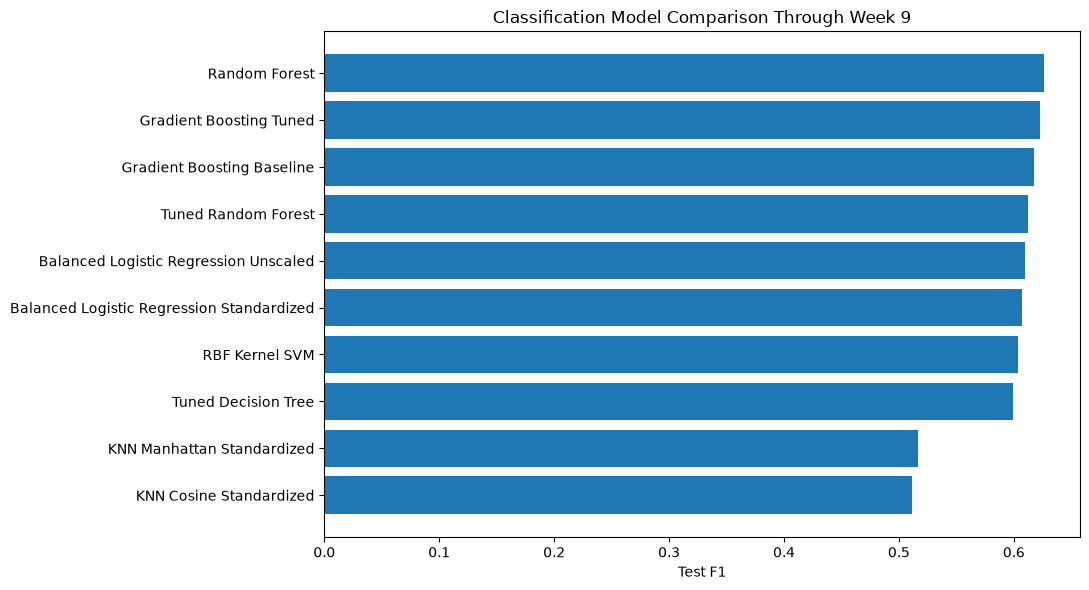

In [235]:
# ============================================================
# 10. Compare Gradient Boosting with prior classifiers
# ============================================================

comparison_through_week9_names = [
    'Random Forest',
    'Tuned Random Forest',
    'Balanced Logistic Regression Unscaled',
    'Balanced Logistic Regression Standardized',
    'RBF Kernel SVM',
    'Tuned Decision Tree',
    'KNN Manhattan Standardized',
    'KNN Cosine Standardized',
    'Gradient Boosting Baseline',
    'Gradient Boosting Tuned']

classification_comparison_week9 = (
    pd.DataFrame(classification_results)
    .drop_duplicates(
        subset='model',
        keep='last'))

classification_comparison_week9 = (
    classification_comparison_week9[
        classification_comparison_week9['model'].isin(
            comparison_through_week9_names)
    ]
    .sort_values(
        'test_f1',
        ascending=False).reset_index(drop=True))

display(classification_comparison_week9)

plt.figure(figsize=(11, 6))

plt.barh(
    classification_comparison_week9['model'],
    classification_comparison_week9['test_f1'])

plt.xlabel('Test F1')
plt.title(
    'Classification Model Comparison Through Week 9')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [237]:
# ============================================================
# Save Week 9 outputs
# ============================================================

week9_results_df.to_csv(
    'week9_gradient_boost_results.csv',
    index=False)

learning_rate_results.to_csv(
    'week9_learning_rate_results.csv',
    index=False)

estimator_results.to_csv(
    'week9_estimator_results.csv',
    index=False)

depth_results.to_csv(
    'week9_tree_depth_results.csv',
    index=False)

regularization_results.to_csv(
    'week9_regularization_results.csv',
    index=False)

gradient_boost_importance_df.to_csv(
    'week9_gradient_boost_feature_importance.csv',
    index=False)

classification_comparison_week9.to_csv(
    'classification_results_through_week9.csv',
    index=False)

print('Week 9 result files saved.')

Week 9 result files saved.
